In [1]:
import csv

csv_path = "kegiatan/sensus-ekonomi-2026/2026/Realisasi - 6104.csv"
with open(csv_path, mode='r', encoding='utf-8-sig') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

print("=== DATA REALISASI SE-2026 KAB. MEMPAWAH ===")
print(f"Total baris data: {len(rows)}")
if rows:
    print("Kolom yang tersedia:", list(rows[0].keys()))


=== DATA REALISASI SE-2026 KAB. MEMPAWAH ===
Total baris data: 31719
Kolom yang tersedia: ['No', 'Kab/Kota', 'Kode Wilayah (Sub-SLS)', 'Username Petugas', 'Email Petugas', 'Role', 'Total Target', 'DRAFT', 'OPEN', 'SUBMITTED RESPONDENT', 'SUBMITTED BY Pencacah', 'APPROVED BY Pengawas', 'REJECTED BY Pengawas', 'REVOKED BY Pengawas', 'COMPLETED BY Admin Kabupaten', 'EDITED BY Admin Kabupaten', 'EDITED BY Pengawas', 'REJECTED BY Admin Kabupaten', '', 'Total Submit PPL', 'Total Submit Seluruh SLS per Petugas', 'Nama PJ', 'Target', '20,78%', 'Ranking', 'Status Target', 'Nama PJ Kuda']


In [2]:
# Analisis ringkas progres Mempawah vs Kabupaten Lain
mempawah_rows = [r for r in rows if r.get('Kab/Kota', '').strip() == 'MEMPAWAH']

total_target = sum(int(r.get('Total Target', 0) or 0) for r in mempawah_rows)
total_draft = sum(int(r.get('DRAFT', 0) or 0) for r in mempawah_rows)
total_submitted = sum(int(r.get('SUBMITTED BY Pencacah', 0) or 0) for r in mempawah_rows)
total_approved = sum(int(r.get('APPROVED BY Pengawas', 0) or 0) for r in mempawah_rows)

completed = total_submitted + total_approved
worked = completed + total_draft

print("=== RINGKASAN AGREGAT MEMPAWAH ===")
print(f"Total Target    : {total_target} unit")
if total_target > 0:
    print(f"Worked Rate     : {worked / total_target * 100:.2f}% ({worked} unit)")
    print(f"Completed Rate  : {completed / total_target * 100:.2f}% ({completed} unit)")
else:
    print("Target tidak ditemukan.")


=== RINGKASAN AGREGAT MEMPAWAH ===
Total Target    : 112473 unit
Worked Rate     : 29.68% (33381 unit)
Completed Rate  : 22.43% (25226 unit)


Grafik visualisasi sukses dibuat dan disimpan di scratch/mempawah_progress.png


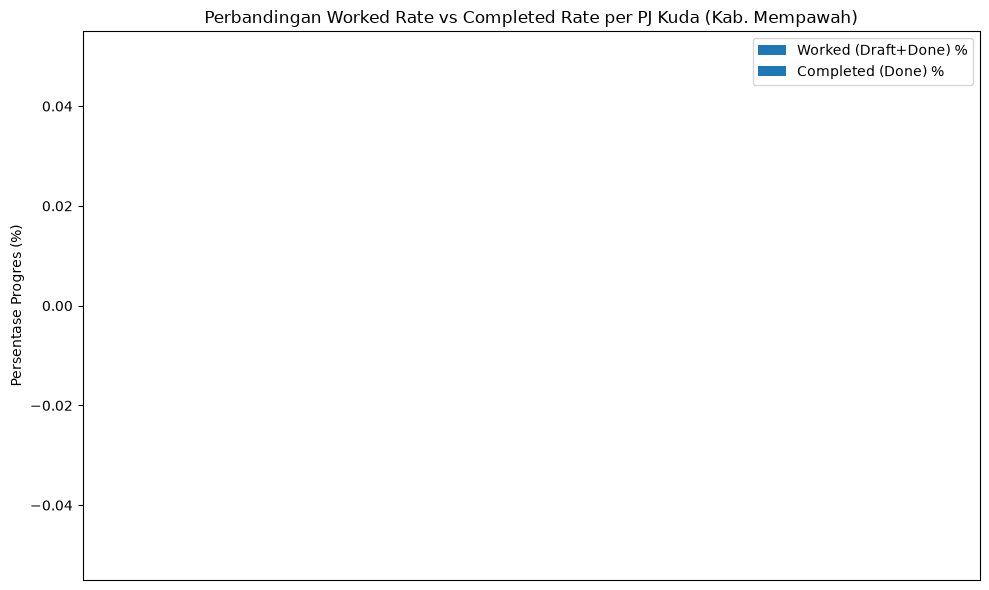

In [3]:
# Visualisasi Progres per PJ Kuda di Kabupaten Mempawah
import matplotlib.pyplot as plt

# Agregasi data per PJ Kuda
pj_stats = {}
for r in rows:
    if r.get('Kab/Kota', '').strip() == 'MEMPAWAH':
        pj = r.get('Nama PJ Kuda', r.get('Nama PJ', '')).strip()
        if not pj:
            continue
        target = int(r.get('Total Target', 0) or 0)
        draft = int(r.get('DRAFT', 0) or 0)
        submitted = int(r.get('SUBMITTED BY Pencacah', 0) or 0)
        approved = int(r.get('APPROVED BY Pengawas', 0) or 0)
        completed = submitted + approved
        worked = completed + draft
        
        pj_stats.setdefault(pj, {'target': 0, 'worked': 0, 'completed': 0})
        pj_stats[pj]['target'] += target
        pj_stats[pj]['worked'] += worked
        pj_stats[pj]['completed'] += completed

# Buat visualisasi
pj_names = sorted(list(pj_stats.keys()))
targets = [pj_stats[pj]['target'] for pj in pj_names]
worked_rates = [pj_stats[pj]['worked'] / pj_stats[pj]['target'] * 100 if pj_stats[pj]['target'] > 0 else 0 for pj in pj_names]
done_rates = [pj_stats[pj]['completed'] / pj_stats[pj]['target'] * 100 if pj_stats[pj]['target'] > 0 else 0 for pj in pj_names]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(pj_names))
width = 0.35

ax.bar([i - width/2 for i in x], worked_rates, width, label='Worked (Draft+Done) %', color='#FFC107')
ax.bar([i + width/2 for i in x], done_rates, width, label='Completed (Done) %', color='#4CAF50')

ax.set_ylabel('Persentase Progres (%)')
ax.set_title('Perbandingan Worked Rate vs Completed Rate per PJ Kuda (Kab. Mempawah)')
ax.set_xticks(x)
ax.set_xticklabels(pj_names, rotation=45, ha='right')
ax.legend()
plt.tight_layout()

# Simpan grafik
plt.savefig('scratch/mempawah_progress.png')
print("Grafik visualisasi sukses dibuat dan disimpan di scratch/mempawah_progress.png")
plt.show()


Mengunduh progres terbaru dari Google Sheets...


Visualisasi diagnostik PPL sukses dibuat di scratch/ppl_diagnostic_quadrant.png


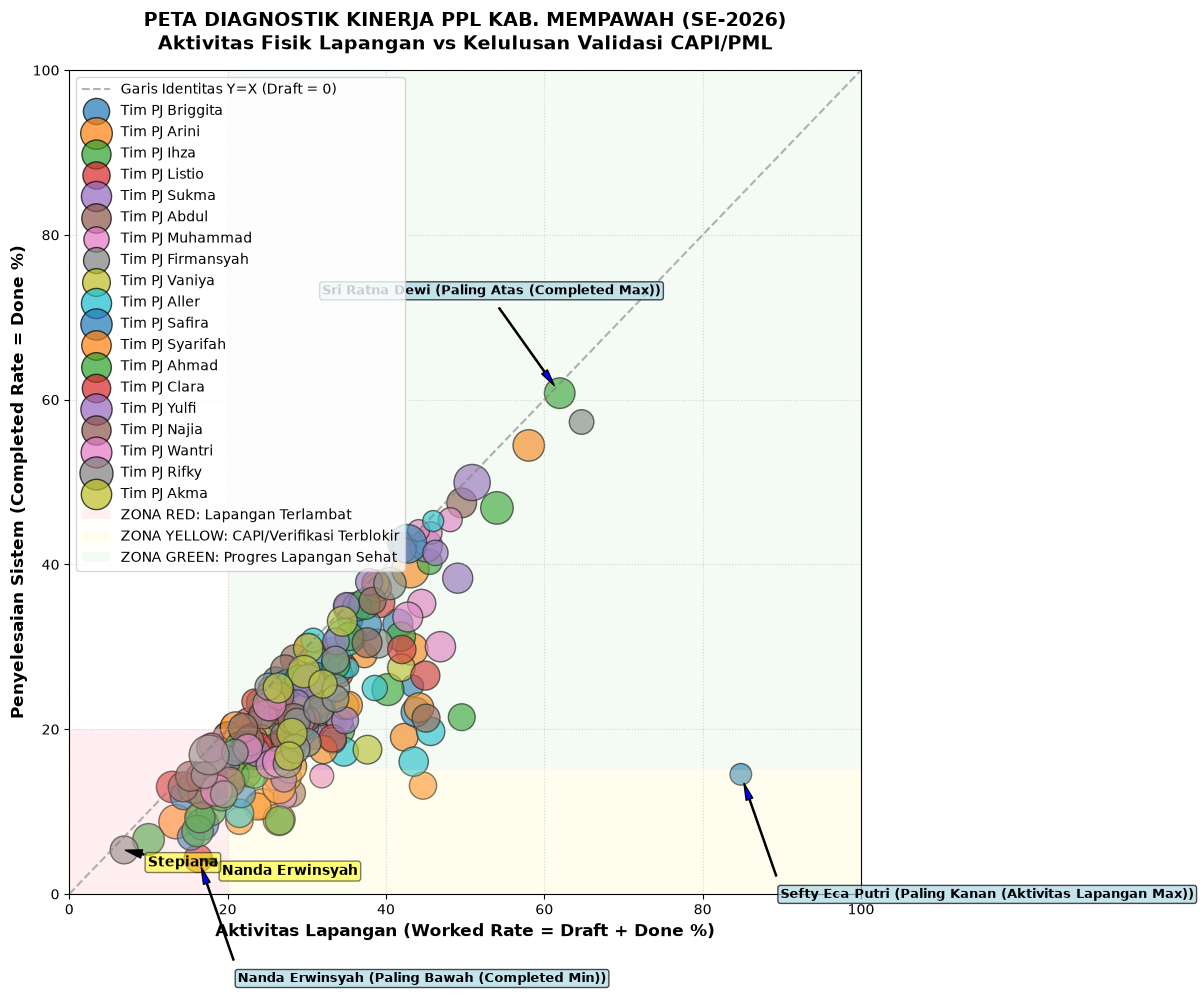

In [4]:
# Analisis Diagnostik PPL: Lapangan vs Sistem CAPI
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Temukan repo root secara dinamis untuk impor modul resmi
root = Path(os.getcwd())
if (root / 'scripts').exists():
    sys.path.append(str(root))
else:
    for p in root.parents:
        if (p / 'scripts').exists():
            sys.path.append(str(p))
            break

from scripts.kb.se_monitor.hierarchy import build_hierarchy
from scripts.kb.se_monitor.data import aggregate_metrics, download_sheet

# Load data resmi
pj_kuda_groups, sls_info, has_alokasi = build_hierarchy()
sheet_map, _, _ = download_sheet()

# Hitung metrik worked vs completed untuk semua PPL
ppl_list = []
for pj_name, pmls in pj_kuda_groups.items():
    for pml_name, ppls in pmls.items():
        for ppl_name, sls_list in ppls.items():
            m = aggregate_metrics(sls_list, sls_info, sheet_map)
            if m['target'] > 0:
                ppl_list.append({
                    'name': ppl_name,
                    'pml': pml_name,
                    'pj': pj_name.split()[0], # Ambil nama depan saja
                    'target': m['target'],
                    'worked_pct': m['worked_rate'] * 100,
                    'completed_pct': m['completed_rate'] * 100
                })

# Konversi ke numpy untuk plotting
worked = np.array([p['worked_pct'] for p in ppl_list])
completed = np.array([p['completed_pct'] for p in ppl_list])
targets = np.array([p['target'] for p in ppl_list])
pjs = [p['pj'] for p in ppl_list]
names = [p['name'] for p in ppl_list]

# Setup plot premium
plt.figure(figsize=(12, 10))
ax = plt.gca()

# Gambar garis identitas Y=X (Progres ideal tanpa draft/antrean)
plt.plot([0, 100], [0, 100], '--', color='gray', alpha=0.6, label='Garis Identitas Y=X (Draft = 0)')

# Warna unik untuk setiap PJ-Kuda (menggunakan API modern plt.colormaps)
unique_pjs = list(set(pjs))
cmap = plt.colormaps['tab10']
pj_colors = {pj: cmap(i % 10) for i, pj in enumerate(unique_pjs)}

# Scatter plot dengan ukuran bubble sebanding dengan target unit sensus PPL
for pj in unique_pjs:
    idx = [i for i, x in enumerate(pjs) if x == pj]
    plt.scatter(
        worked[idx], completed[idx], 
        s=targets[idx]*0.8, # Ukuran titik
        color=pj_colors[pj], 
        alpha=0.7, 
        edgecolors='black', 
        label=f'Tim PJ {pj}'
    )

# Shading Diagnostic Quadrants
# Zona 1: Lapangan Terlambat (Worked < 20% & Completed < 20%)
rect_delayed = plt.Rectangle((0, 0), 20, 20, facecolor='#FFCDD2', alpha=0.3, label='ZONA RED: Lapangan Terlambat')
ax.add_patch(rect_delayed)

# Zona 2: CAPI Terblokir (Worked > 20% tetapi Completed < 15%)
rect_blocked = plt.Rectangle((20, 0), 80, 15, facecolor='#FFF9C4', alpha=0.3, label='ZONA YELLOW: CAPI/Verifikasi Terblokir')
ax.add_patch(rect_blocked)

# Zona 3: Progres Sehat (Worked > 20% & Completed >= 15%)
rect_healthy = plt.Rectangle((20, 15), 80, 85, facecolor='#C8E6C9', alpha=0.2, label='ZONA GREEN: Progres Lapangan Sehat')
ax.add_patch(rect_healthy)

# Cari PPL ekstrim untuk dilabeli secara otomatis
ppl_paling_kanan = max(ppl_list, key=lambda x: x['worked_pct'])
ppl_paling_atas = max(ppl_list, key=lambda x: x['completed_pct'])
started_ppl = [p for p in ppl_list if p['worked_pct'] > 0]
ppl_paling_bawah = min(started_ppl, key=lambda x: x['completed_pct'])

# Buat daftar label ekstrim unik (menghindari duplikasi jika orang yang sama memegang multi-rekor)
extreme_labels = {}
extreme_labels[ppl_paling_kanan['name']] = extreme_labels.get(ppl_paling_kanan['name'], []) + ['Paling Kanan (Aktivitas Lapangan Max)']
extreme_labels[ppl_paling_atas['name']] = extreme_labels.get(ppl_paling_atas['name'], []) + ['Paling Atas (Completed Max)']
extreme_labels[ppl_paling_bawah['name']] = extreme_labels.get(ppl_paling_bawah['name'], []) + ['Paling Bawah (Completed Min)']

# Anotasi PPL Terkritis (Nanda Erwinsyah & Stepiana)
for p in ppl_list:
    if p['name'] in ['Nanda Erwinsyah', 'Stepiana']:
        plt.annotate(
            p['name'], 
            xy=(p['worked_pct'], p['completed_pct']), 
            xytext=(p['worked_pct']+3, p['completed_pct']-2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.5)
        )

# Anotasi PPL Ekstrim Dinamis
for p in ppl_list:
    if p['name'] in extreme_labels:
        desc = " & ".join(extreme_labels[p['name']])
        y_offset = 12 if p['name'] == ppl_paling_atas['name'] else -15
        x_offset = -30 if p['name'] == ppl_paling_atas['name'] else 5
        plt.annotate(
            f"{p['name']} ({desc})", 
            xy=(p['worked_pct'], p['completed_pct']), 
            xytext=(p['worked_pct'] + x_offset, p['completed_pct'] + y_offset),
            arrowprops=dict(facecolor='blue', shrink=0.08, width=0.8, headwidth=5),
            fontsize=9, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='lightblue', alpha=0.7)
        )

# Labeling
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('Aktivitas Lapangan (Worked Rate = Draft + Done %)', fontsize=12, fontweight='bold')
plt.ylabel('Penyelesaian Sistem (Completed Rate = Done %)', fontsize=12, fontweight='bold')
plt.title('PETA DIAGNOSTIK KINERJA PPL KAB. MEMPAWAH (SE-2026)\nAktivitas Fisik Lapangan vs Kelulusan Validasi CAPI/PML', fontsize=14, fontweight='bold', pad=15)

# Grid premium
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='upper left', scatterpoints=1, fontsize=10)
plt.tight_layout()

# Simpan visualisasi diagnostik
plt.savefig('scratch/ppl_diagnostic_quadrant.png', dpi=150)
print("Visualisasi diagnostik PPL sukses dibuat di scratch/ppl_diagnostic_quadrant.png")
plt.show()


Visualisasi diagnostik PPL Se-Kalbar sukses dibuat di scratch/kalbar_diagnostic_quadrant.png


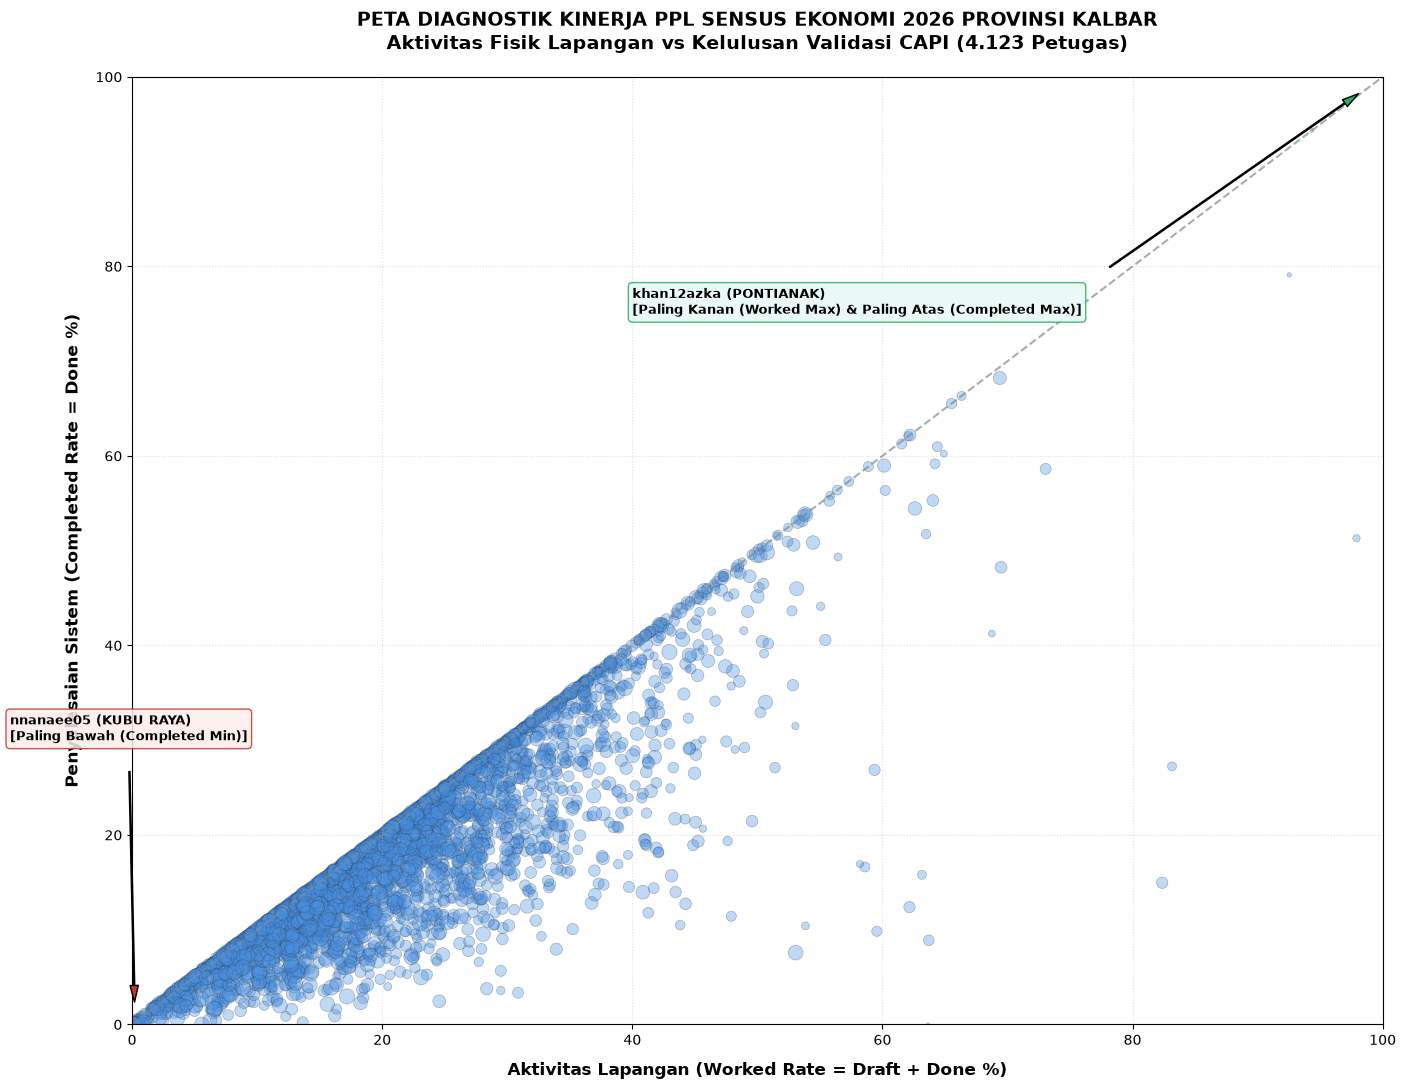

In [5]:
# Analisis Diagnostik PPL Se-Kalimantan Barat (Monochrome & No Legend)
import csv
import matplotlib.pyplot as plt
import numpy as np

# Load data CAPI realisasi
csv_path = "kegiatan/sensus-ekonomi-2026/2026/Realisasi - 6104.csv"
with open(csv_path, mode='r', encoding='utf-8-sig') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# Agregasi berdasarkan Username Petugas dan Kab/Kota
ppl_stats = {}
for r in rows:
    p = r.get('Username Petugas')
    kab = r.get('Kab/Kota')
    if not p or not kab: 
        continue
    p = p.strip()
    kab = kab.strip()
    t = int(r.get('Total Target', 0) or 0)
    d = int(r.get('DRAFT', 0) or 0)
    s = int(r.get('SUBMITTED BY Pencacah', 0) or 0)
    a = int(r.get('APPROVED BY Pengawas', 0) or 0)
    c = s + a
    w = c + d
    
    ppl_stats.setdefault((p, kab), {'target': 0, 'worked': 0, 'completed': 0})
    ppl_stats[(p, kab)]['target'] += t
    ppl_stats[(p, kab)]['worked'] += w
    ppl_stats[(p, kab)]['completed'] += c

# Buat daftar PPL dengan koordinat persentase
ppl_list = []
for (p, kab), stats in ppl_stats.items():
    if stats['target'] > 0:
        ppl_list.append({
            'email': p,
            'name': p.split('@')[0], # Ambil username CAPI
            'kab': kab,
            'target': stats['target'],
            'worked_pct': (stats['worked'] / stats['target']) * 100,
            'completed_pct': (stats['completed'] / stats['target']) * 100
        })

# Ekstrak koordinat untuk plotting
worked = np.array([p['worked_pct'] for p in ppl_list])
completed = np.array([p['completed_pct'] for p in ppl_list])
targets = np.array([p['target'] for p in ppl_list])

# Setup plot premium monochrome
plt.figure(figsize=(14, 11))
ax = plt.gca()

# Gambar garis identitas Y=X (Draft = 0)
plt.plot([0, 100], [0, 100], '--', color='#7F8C8D', alpha=0.7, linewidth=1.5)

# Scatter plot semua 4123 PPL dengan warna netral seragam (steel blue) tanpa legenda
plt.scatter(
    worked, completed, 
    s=np.clip(targets * 0.15, 5, 120), # Ukuran bubble adaptif agar tidak menutupi grafik
    color='#4A90E2', 
    alpha=0.35, 
    edgecolors='#2C3E50', 
    linewidths=0.5
)

# Cari PPL ekstrim tingkat provinsi (Sekalbar) dengan bobot target terbesar jika ada nilai kembar
# 1. Paling Kanan (Aktivitas Lapangan Terbesar)
max_w = max(p['worked_pct'] for p in ppl_list)
ppl_paling_kanan = max([p for p in ppl_list if p['worked_pct'] == max_w], key=lambda x: x['target'])

# 2. Paling Atas (Completed Rate Terbesar)
max_c = max(p['completed_pct'] for p in ppl_list)
ppl_paling_atas = max([p for p in ppl_list if p['completed_pct'] == max_c], key=lambda x: x['target'])

# 3. Paling Bawah (Completed Rate Terkecil di antara yang sudah mulai lapangan)
started_ppl = [p for p in ppl_list if p['worked_pct'] > 0]
min_c = min(p['completed_pct'] for p in started_ppl)
ppl_paling_bawah = max([p for p in started_ppl if p['completed_pct'] == min_c], key=lambda x: x['target'])

# Kelompokkan anotasi ekstrim untuk menghindari tumpang tindih teks
extreme_labels = {}
extreme_labels[ppl_paling_kanan['email']] = extreme_labels.get(ppl_paling_kanan['email'], []) + ['Paling Kanan (Worked Max)']
extreme_labels[ppl_paling_atas['email']] = extreme_labels.get(ppl_paling_atas['email'], []) + ['Paling Atas (Completed Max)']
extreme_labels[ppl_paling_bawah['email']] = extreme_labels.get(ppl_paling_bawah['email'], []) + ['Paling Bawah (Completed Min)']

# Anotasi PPL Ekstrim dinamis sekalbar
for p in ppl_list:
    if p['email'] in extreme_labels:
        desc = " & ".join(extreme_labels[p['email']])
        # Tentukan posisi teks agar terbaca jelas
        if p['email'] == ppl_paling_atas['email']:
            x_offset, y_offset = -60, -25
            arrow_color = '#27AE60'
            bg_color = '#E8F8F5'
        elif p['email'] == ppl_paling_bawah['email']:
            x_offset, y_offset = -10, 30
            arrow_color = '#C0392B'
            bg_color = '#FDEDEC'
        else:
            x_offset, y_offset = 15, -15
            arrow_color = '#2980B9'
            bg_color = '#EBF5FB'
            
        plt.annotate(
            f"{p['name']} ({p['kab']})\n[{desc}]", 
            xy=(p['worked_pct'], p['completed_pct']), 
            xytext=(p['worked_pct'] + x_offset, p['completed_pct'] + y_offset),
            arrowprops=dict(facecolor=arrow_color, shrink=0.08, width=0.8, headwidth=6),
            fontsize=9.5, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.3', fc=bg_color, ec=arrow_color, alpha=0.85)
        )

# Labeling & Axis (Tanpa Legenda dan Shading Warna)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('Aktivitas Lapangan (Worked Rate = Draft + Done %)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Penyelesaian Sistem (Completed Rate = Done %)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('PETA DIAGNOSTIK KINERJA PPL SENSUS EKONOMI 2026 PROVINSI KALBAR\nAktivitas Fisik Lapangan vs Kelulusan Validasi CAPI (4.123 Petugas)', fontsize=14, fontweight='bold', pad=20)

# Grid premium
plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()

# Simpan visualisasi diagnostik sekalbar
plt.savefig('scratch/kalbar_diagnostic_quadrant.png', dpi=150)
print("Visualisasi diagnostik PPL Se-Kalbar sukses dibuat di scratch/kalbar_diagnostic_quadrant.png")
plt.show()
